# Tutorial: Setting Up Star Formation-Rate Dictionary

This notebook demonstrates how to construct star formation rate dictionaries (`sfr_dict`), plot them, and highlight key considerations.

The star formation rate (SFR) history is stored in a dictionary called `sfr_dict`. The dictionary includes entries for the global star formation rate (`starformation_rate_array`), information about the bins in which this star formation rate is defined (either based on lookback time, `lookback_time_bin_edges`, or based on redshift, `redshift_bin_edges`) and, optionally, information about the metallicity distribution (`metallicity_distribution_array`) and its bins (`metallicity_bin_edges`). This information has to be provided in arrays, and they are used as such in the convolution. That means that any normalisation over the (global) range is the responsibility of the user. 

An example `sfr_dict` looks like this

```python
sfr_dict = {
    'lookback_time_bin_edges': np.arange(0, 10, 1) * u.Gyr,
    'starformation_rate_array': np.ones(9) * u.Msun / u.yr
    'metallicity_bin_edges': np.array([0.001, 0.01, 0.1, 1]),
    'metallicity_distribution_array': np.ones(9,3) * 0.33
}
```

For more details on both the global star formation rate information and the metallicity information, see the following sections.

### Configuring the Global Star Formation Rate
The first step to configuring the `sfr_dict` is by providing information about the global star formation rate over a range of times. 

To configure the SFR history, provide the `sfr_dict` with :

- `lookback_time_bin_edges` or `redshift_bin_edges`: 1-D array of bin edges for lookback time (astropy units are required here), or redshift.
- `starformation_array`: 1-D array of SFR values at bin centers. Must have astropy units (but they can be anything, to support different types of SFR information) and must be one element shorter than the bin edges array.

We can perform a convolution based on only a global star formation rate, so providing the above-mentioned entries will be enough for a functioning convolution.

Some functions to generate known SFR distributions are provided in `syntheticstellarpopconvolve.starformation_rate_distributions.py`.

### Adding Metallicity Dependence (Optional)
Often, however, we want to convolve our stellar population information taking into account a range of metallicities. This is supported if you include the following information to the `sfr_dict`:

- `metallicity_bin_edges`: 1-D array of metallicity bin edges.
- `metallicity_distribution_array`: 2-D array of metallicity distribution as a function of time/redshift and metallicity. Must have dimensions:
  - One less than `lookback_time_bin_edges` or `redshift_bin_edges` in time dimension.
  - One less than `metallicity_bin_edges` in metallicity dimension.

The `metallicity_distribution_array` should not already contain the starformation rate information, as internally `metallicity_distribution_array` gets multiplied by `starformation_array` to create the `metallicity_weighted_starformation_array`.

It is important to note here that the metallicity information is assumed to be linear in metallicity (Z). Generally metallicity distributions are proportional to $\mathrm{log}_{10}(Z)$, or in dex ([[Fe/H]](https://en.wikipedia.org/wiki/Metallicity#Chemical_abundance_ratios), a logarithmic scale relative to the solar value) but for technical reasons storing everything in linear-metallicity is currently more convenient. Make sure to convert your metallicity information to be linear in Z! It is then also relevant that the actual metallicity where the value comes from does not have to be in the center of the linear-bin per se. For plotting purposes, one _can_ provide the additional information `metallicity_scale`, which can be `linear`, `log10`, and `log`.

Some functions to generate known metallicity distributions are provided in `syntheticstellarpopconvolve.metallicity_distributions.py`.


### Some important general  things to note:
- While the `starformation_rate_array` describes the star formation rate in the center of the time bins, we provide the time bin information through the edges. Centers and sizes of these bins will be automatically calculated internally.




### Additional Information

Various star formation rate and metallicity distribution functions are available in `syntheticstellarpopconvolve.starformation_rate_distributions` and `syntheticstellarpopconvolve.metallicity_distributions`.


## Passing to convolution config
Once you have created an `sfr_dict` it should be passed to the config in `SFR_info` like

```Python
convolution_config['SFR_info'] = sfr_dict
```

TThere are internal checks to ensure the that you have configured the `sfr_dict` properly, and if not, you'll be warned before the convolution starts. These checks are done in the function `check_sfr_dict` available in `syntheticstellarpopconvolve.check_convolution_config`.

It is possible to provide multiple different `sfr_dict`s to the convolution config. This is done as follows:

```Python
convolution_config['SFR_info'] = [sfr_dict_1, sfr_dict_2, ...]
```

The `sfr_dicts` require an additional field, `name`, to distinguish them in the output structure, and they will be stored in the output hdf5 under `output_data/<name>/...` instead of `output_data/...` for a singular `sfr_dict`. These sfr_dicts will then be handled sequentially in the convolution code (whereas the convolution of each of them is done using multiprocessing)

## Plotting an sfr dict
For convenience we provide a function to visualise the data stored in a `sfr_dict` through `plot_sfr_dict` available in `syntheticstellarpopconvolve.SFR_dict_plotting_routines.py`. This function will plot the global star formation rate, and potentially the metallicity-weighted star formation rate. Call `help(plot_sfr_dict)` to see the necessary parameters and options. Particularly, this function can be configured to return the figure and the axis objects in a dictionary called `axis_dict`, by passing `return_axis_dict=True`. In this way one can modify the axes and their contents. 

[0.00316228 0.03162278 0.31622777]
[[0.5 1.5 2.5 3.5]
 [0.5 1.5 2.5 3.5]
 [0.5 1.5 2.5 3.5]] Gyr [[0.00316228 0.00316228 0.00316228 0.00316228]
 [0.03162278 0.03162278 0.03162278 0.03162278]
 [0.31622777 0.31622777 0.31622777 0.31622777]] [[0.33667272 0.0499694  0.50132154 0.7991874 ]
 [0.46000555 0.20823334 0.55305228 0.53113769]
 [0.29110987 0.5137647  0.12238338 0.01459752]] solMass / yr


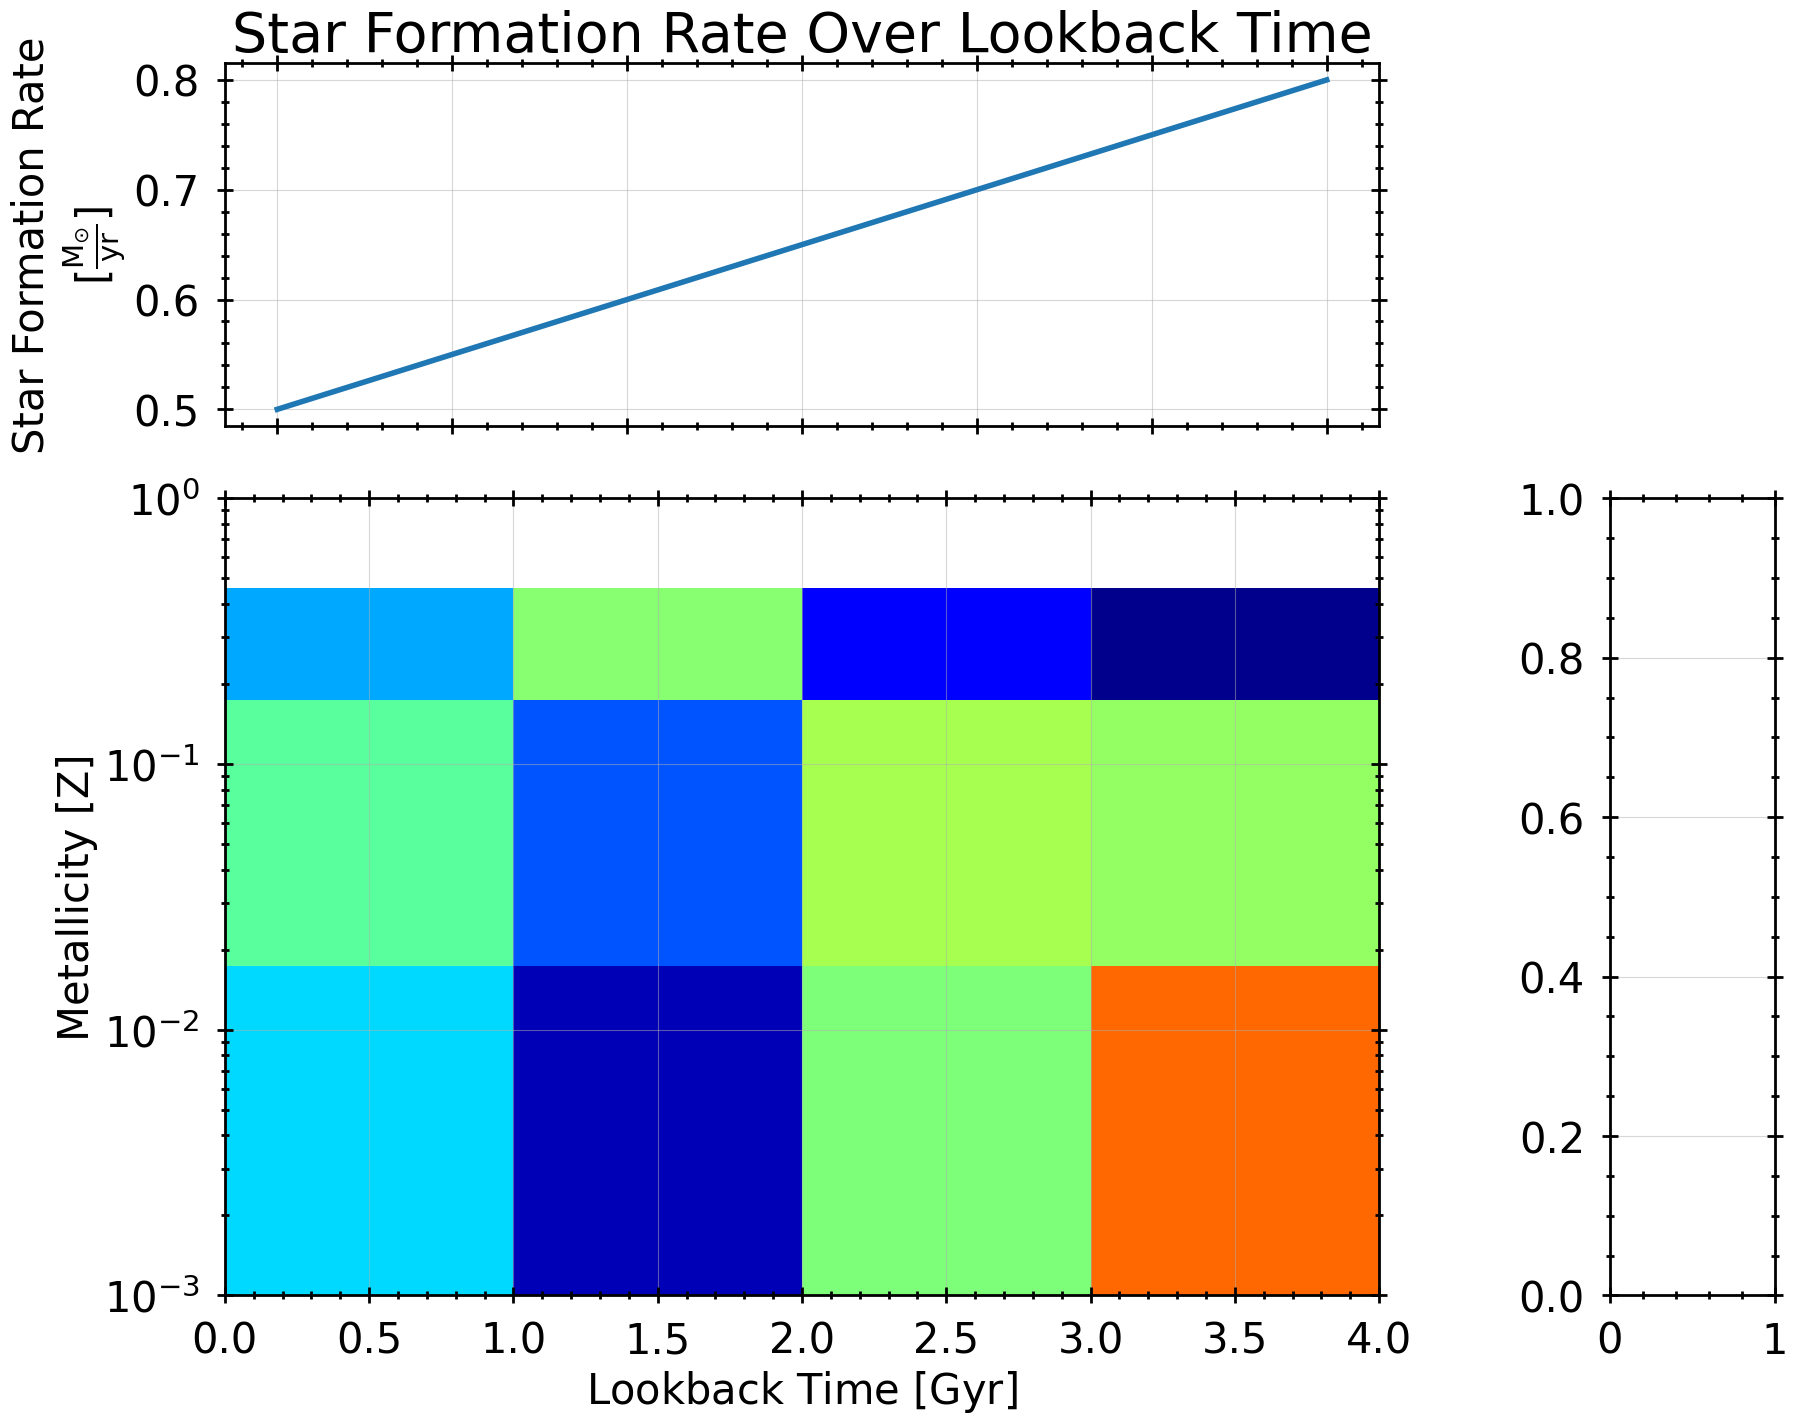

In [1]:
import copy
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import colors

from syntheticstellarpopconvolve.check_and_update_sfr_dict import check_and_update_sfr_dict
import astropy.units as u
import logging

from syntheticstellarpopconvolve.SFR_dict_plotting_routines import load_mpl_rc
def plot_sfr_dict(sfr_dict, time_type, return_axis_dict=False, metallicity_scale='linear'):
    """
    Function to plot the star formation rate
    """

    load_mpl_rc()
    
    # check if there is any metallicity info
    has_metallicity_info = "metallicity_bin_edges" in sfr_dict and "metallicity_distribution_array" in sfr_dict

    # check and update the sfr dict
    sfr_dict = check_and_update_sfr_dict(
        sfr_dict=sfr_dict,
        config={'logger': logging.getLogger(__name__), 'time_type': time_type},
        requires_name=False,
        requires_metallicity_info=has_metallicity_info,
        time_type=time_type
    )
    print(sfr_dict['metallicity_bin_centers'])
        
    ########
    # Set up figure canvas
    axis_dict = {}
    axis_dict['fig'] = plt.figure(figsize=(20, 16 if has_metallicity_info else 6))

    if has_metallicity_info:
        gs = axis_dict['fig'].add_gridspec(nrows=3, ncols=8)

        axis_dict['ax_sfr'] = axis_dict['fig'].add_subplot(gs[0, :-2])
        axis_dict['ax_mssfr'] = axis_dict['fig'].add_subplot(gs[1:, :-2])
        ax_bar = axis_dict['fig'].add_subplot(gs[1:, -1])

        axis_dict['ax_bar'] = ax_bar
    else:

        gs = axis_dict['fig'].add_gridspec(nrows=1, ncols=2)

        axis_dict['ax_sfr'] = axis_dict['fig'].add_subplot(gs[0, :])

    ########
    # Plot Star Formation Rate (SFR)
    if time_type == "lookback_time" and "time_bin_edges" in sfr_dict and "starformation_rate_array" in sfr_dict:
        time_bin_edges = sfr_dict["time_bin_centers"]
        sfr_array = sfr_dict["starformation_rate_array"]

        axis_dict['ax_sfr'].plot(time_bin_edges, sfr_array)        
        axis_dict['ax_sfr'].set_xlabel("Lookback Time [{}]".format(sfr_dict["time_bin_centers"].unit.to_string("latex")))
        axis_dict['ax_sfr'].set_ylabel("Star Formation Rate\n[{}]".format(sfr_dict['starformation_rate_array'].unit.to_string("latex")))
        axis_dict['ax_sfr'].set_title("Star Formation Rate Over Lookback Time")

    ########
    # Plot the metallicity
    if has_metallicity_info:
        # Set up the meshgrid that we will use
        time_mesh, metallicity_mesh = np.meshgrid(
            sfr_dict["time_bin_centers"],
            sfr_dict["metallicity_bin_centers"]
        )
        print(time_mesh, metallicity_mesh, sfr_dict['metallicity_weighted_starformation_rate_array'])
        cmap_metallicity_fraction_hist = copy.copy(plt.cm.jet)
        metallicity_fraction_hist_plot = axis_dict['ax_mssfr'].pcolormesh(
            time_mesh.value,
            metallicity_mesh,
            sfr_dict['metallicity_weighted_starformation_rate_array'].value,
            norm=colors.Normalize(vmin=1e-8, vmax=1),
            cmap=cmap_metallicity_fraction_hist,
            shading="auto",
            antialiased=True,
            rasterized=True
        )

        #
        axis_dict['ax_sfr'].set_xlabel('')
        axis_dict['ax_sfr'].set_xticklabels([])
        axis_dict['ax_mssfr'].set_xlabel("Lookback Time [{}]".format(sfr_dict["time_bin_centers"].unit.to_string("latex")))
        axis_dict['ax_mssfr'].set_ylabel("Metallicity [Z]")
        axis_dict['ax_mssfr'].set_ylim([sfr_dict["metallicity_bin_edges"].min(), sfr_dict["metallicity_bin_edges"].max()])
    
    #############
    # 
    if return_axis_dict:
        return axis_dict

# Example usage with a sample sfr_dict (fill with actual data to test)
sample_sfr_dict = {
    "lookback_time_bin_edges": np.array([0, 1, 2, 3, 4]) * u.Gyr,
    "starformation_rate_array": np.array([0.5, 0.6, 0.7, 0.8]) * u.Msun/u.yr,
    "metallicity_bin_edges": np.array([0.001, 0.01, 0.1, 1]),
    "metallicity_distribution_array": np.random.rand(4, 3).T,  # Example 2D metallicity distribution
    "metallicity_scale": 'log10'
}

sample_config = {"logger": print, "time_type": "lookback_time"}

axis_dict = plot_sfr_dict(sample_sfr_dict, time_type='lookback_time', return_axis_dict=True)

axis_dict['ax_mssfr'].set_yscale('log')